In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from dist_s1.data_models.output_models import DistS1ProductDirectory, compare_product_layer_tags, compare_product_raster
from tqdm import tqdm
from pathlib import Path
import concurrent.futures
import rasterio
import numpy as np
import matplotlib.pyplot as plt


In [3]:
PROVISIONAL_PRODUCT_PREFIX = 's3://opera-pst-rs-pop1/products/DIST_S1/'

In [4]:
VAL_ADT_PREFIX = 'validation_data_2026'
VAL_BUCKET = 'dist-s1-golden-datasets'

In [5]:
import boto3

def list_s3_subfolders(bucket, prefix):
    client = boto3.client('s3')
    prefix = prefix if prefix.endswith('/') else f"{prefix}/"
    response = client.list_objects_v2(Bucket=bucket, Prefix=prefix, Delimiter='/')
    return [f"s3://{bucket}/{cp['Prefix']}" for cp in response.get('CommonPrefixes', [])]

In [6]:
ts_dirs = list_s3_subfolders(VAL_BUCKET, VAL_ADT_PREFIX)
ts_dirs

['s3://dist-s1-golden-datasets/validation_data_2026/builtnewalert__16SBF/',
 's3://dist-s1-golden-datasets/validation_data_2026/gen__12STA/',
 's3://dist-s1-golden-datasets/validation_data_2026/wetshort__37VDH/']

In [58]:
MGRS_TILE = '12STA'
MGRS_TILE = '16SBF'
MGRS_TILE = '37VDH'

In [59]:
PREFIX_MGRS = ['/'.join(d.split('/')[3:]) for d in ts_dirs if MGRS_TILE in d][0]
PREFIX_MGRS

'validation_data_2026/wetshort__37VDH/'

In [60]:
ref_ts_prods = sorted(list_s3_subfolders(VAL_BUCKET, PREFIX_MGRS))
ref_ts_prods[:3]

['s3://dist-s1-golden-datasets/validation_data_2026/wetshort__37VDH/OPERA_L3_DIST-ALERT-S1_T37VDH_20240108T151618Z_20260205T203548Z_S1A_30_v0.1/',
 's3://dist-s1-golden-datasets/validation_data_2026/wetshort__37VDH/OPERA_L3_DIST-ALERT-S1_T37VDH_20240120T151618Z_20260205T203556Z_S1A_30_v0.1/',
 's3://dist-s1-golden-datasets/validation_data_2026/wetshort__37VDH/OPERA_L3_DIST-ALERT-S1_T37VDH_20240201T151617Z_20260205T203608Z_S1A_30_v0.1/']

In [61]:
with open('products_in_s3.txt') as f:
    products = list([line.strip() for line in f.readlines()])
    s3_uris_sds = [f'{PROVISIONAL_PRODUCT_PREFIX}{p}' for p in products]
sds_ts_prods = sorted([d for d in s3_uris_sds if MGRS_TILE in d])
sds_ts_prods[:3]

['s3://opera-pst-rs-pop1/products/DIST_S1/OPERA_L3_DIST-ALERT-S1_T37VDH_20240108T151618Z_20260410T205029Z_S1A_30_v0.1/',
 's3://opera-pst-rs-pop1/products/DIST_S1/OPERA_L3_DIST-ALERT-S1_T37VDH_20240120T151618Z_20260410T232058Z_S1A_30_v0.1/',
 's3://opera-pst-rs-pop1/products/DIST_S1/OPERA_L3_DIST-ALERT-S1_T37VDH_20240201T151617Z_20260411T002833Z_S1A_30_v0.1/']

In [62]:
sds_acq_ts = [pd.to_datetime(Path(p).stem.split('_')[4]) for p in sds_ts_prods]
sds_acq_ts[:3]

[Timestamp('2024-01-08 15:16:18+0000', tz='UTC'),
 Timestamp('2024-01-20 15:16:18+0000', tz='UTC'),
 Timestamp('2024-02-01 15:16:17+0000', tz='UTC')]

In [63]:
adt_acq_ts = [pd.to_datetime(Path(p).stem.split('_')[4]) for p in ref_ts_prods]
adt_acq_ts[:3]

[Timestamp('2024-01-08 15:16:18+0000', tz='UTC'),
 Timestamp('2024-01-20 15:16:18+0000', tz='UTC'),
 Timestamp('2024-02-01 15:16:17+0000', tz='UTC')]

In [64]:
sds_missing_dates = [ts for ts in adt_acq_ts if ts not in sds_acq_ts]
adt_missing_dates = [ts for ts in sds_acq_ts if ts not in adt_acq_ts]
len(sds_missing_dates), len(adt_missing_dates)

(0, 0)

In [65]:
len(sds_ts_prods), len(ref_ts_prods)

(30, 30)

In [66]:
# prods_sds = [DistS1ProductDirectory.from_product_path(p) for p in tqdm(sds_ts_prods)]
# prods_adt = [DistS1ProductDirectory.from_product_path(p) for p in tqdm(ref_ts_prods)]

with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
    prods_sds = list(tqdm(executor.map(DistS1ProductDirectory.from_product_path, sds_ts_prods), total=len(sds_ts_prods)))
    prods_adt = list(tqdm(executor.map(DistS1ProductDirectory.from_product_path, ref_ts_prods), total=len(ref_ts_prods)))


100%|██████████| 30/30 [00:09<00:00,  3.07it/s]


In [67]:
def check_tags(prod_0, prod_1):
    return compare_product_layer_tags(prod_0, prod_1, ignore_tags=['prior_dist_s1_product'])

In [68]:
prods_adt[1], prods_sds[1]

(DistS1ProductDirectory(product_name='OPERA_L3_DIST-ALERT-S1_T37VDH_20240120T151618Z_20260205T203556Z_S1A_30_v0.1', dst_dir='s3://dist-s1-golden-datasets/validation_data_2026/wetshort__37VDH'),
 DistS1ProductDirectory(product_name='OPERA_L3_DIST-ALERT-S1_T37VDH_20240120T151618Z_20260410T232058Z_S1A_30_v0.1', dst_dir='s3://opera-pst-rs-pop1/products/DIST_S1'))

In [69]:
from functools import partial
compare_product_raster_metric = partial(compare_product_raster, layer='GEN-METRIC')
compare_product_raster_status = partial(compare_product_raster, layer='GEN-DIST-STATUS')

with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
    raster_checks_metric = list(tqdm(executor.map(compare_product_raster_metric, prods_adt, prods_sds), total=len(prods_adt)))
    raster_checks_status = list(tqdm(executor.map(compare_product_raster_status, prods_adt, prods_sds), total=len(prods_adt)))

100%|██████████| 30/30 [00:01<00:00, 19.98it/s]


In [70]:
raster_bool_metric = [r.is_equal for r in raster_checks_metric]
raster_bool_status = [r.is_equal for r in raster_checks_status]
raster_bool_metric[:]


[True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True]

In [71]:
raster_bool_status[4]

False

In [72]:
with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
    ts_check_tags = list(tqdm(executor.map(check_tags, prods_adt, prods_sds), total=len(prods_adt)))
    

100%|██████████| 30/30 [00:00<00:00, 285975.27it/s]


In [73]:
all([t.all_match for t in ts_check_tags])

True

In [74]:
def check_sequential(dist_s1_products: list) -> bool:
    output_prods = []
    ordered_correctly = []
    for k, prod in enumerate(tqdm(dist_s1_products)):
        if k == 0:
            with rasterio.open(prod.layer_path_dict['GEN-DIST-STATUS']) as src:
                t = src.tags()
            prior_dist_s1_product = t['prior_dist_s1_product']
            prior_dist_s1_product = prior_dist_s1_product.split('/')[-1]
            output_prods.append(prior_dist_s1_product)
            ordered_correctly.append(True)
        else:
            with rasterio.open(prod.layer_path_dict['GEN-DIST-STATUS']) as src:
                t = src.tags()
            prior_dist_s1_product = t['prior_dist_s1_product']
            prior_dist_s1_product = prior_dist_s1_product.split('/')[-1]
            output_prods.append(prior_dist_s1_product)
            ordered_correctly.append(prior_dist_s1_product == str(dist_s1_products[k-1]).split('/')[-1])
    return output_prods, ordered_correctly

prods_l, valid_prior = check_sequential(prods_sds)


100%|██████████| 30/30 [00:02<00:00, 14.70it/s]


In [75]:
all(valid_prior)

True

In [76]:
sample_prod_adt = prods_adt[1]
sample_prod_sds = prods_sds[1]

with rasterio.open(sample_prod_adt.layer_path_dict['GEN-METRIC']) as src:
    status_adt = src.read(1)
with rasterio.open(sample_prod_sds.layer_path_dict['GEN-METRIC']) as src:
    status_sds = src.read(1)

max diff: 5.587935447692871e-06


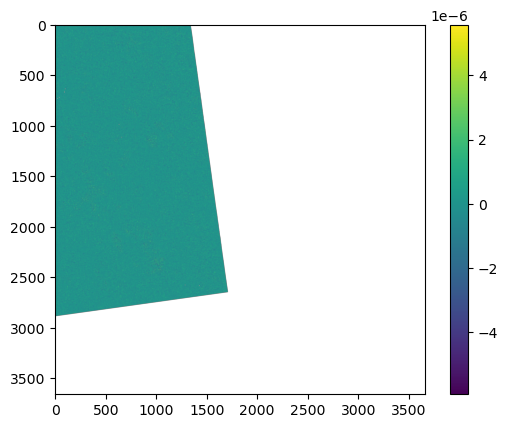

In [77]:
import matplotlib.pyplot as plt

m = np.nanmax(status_sds - status_adt) 
print(f'max diff: {m}')
plt.imshow(status_sds - status_adt)
plt.colorbar()

In [78]:
prods_adt[1] == prods_sds[1]

/Users/cmarshak/bekaert-team/dist-s1/src/dist_s1/data_models/output_models.py:454: UserWarning: Layer GEN-DIST-STATUS: 1 tags do not match: prior_dist_s1_product: 'None' != '/home/ops/input_dir/OPERA_L3_DIST-ALERT-S1_T37VDH_20240108T151618Z_20260410T205029Z_S1A_30_v0.1'
  warn(
/Users/cmarshak/bekaert-team/dist-s1/src/dist_s1/data_models/output_models.py:454: UserWarning: Layer GEN-METRIC: 1 tags do not match: prior_dist_s1_product: 'None' != '/home/ops/input_dir/OPERA_L3_DIST-ALERT-S1_T37VDH_20240108T151618Z_20260410T205029Z_S1A_30_v0.1'
  warn(
/Users/cmarshak/bekaert-team/dist-s1/src/dist_s1/data_models/output_models.py:454: UserWarning: Layer GEN-DIST-STATUS-ACQ: 1 tags do not match: prior_dist_s1_product: 'None' != '/home/ops/input_dir/OPERA_L3_DIST-ALERT-S1_T37VDH_20240108T151618Z_20260410T205029Z_S1A_30_v0.1'
  warn(
/Users/cmarshak/bekaert-team/dist-s1/src/dist_s1/data_models/output_models.py:454: UserWarning: Layer GEN-METRIC-MAX: 1 tags do not match: prior_dist_s1_product: 'N

False

In [79]:
8.940697e-06 > 2.000000e-05

False